In [19]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

from src.data_structures.linked_list import Linked_List_Compra, Linked_List_Venda
from src.data_structures.node import Node
from src.data_structures.ordem import Ordem
from src.data_structures.queue import Queue
from src.data_structures.stack import Stack

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
import re

## 1. Configuração: localizando os arquivos CSV

In [20]:
diretorio_dados = Path('/mnt/hd/trabalho-ed/Trabalho-ED')

def numero_do_arquivo(caminho):
    """Extrai o número do nome do arquivo (orders_3.csv -> 3) para ordenar corretamente
    (evita que 'orders_10.csv' venha antes de 'orders_2.csv' na ordenação alfabética)."""
    match = re.search(r'(\d+)', caminho.stem)
    return int(match.group(1)) if match else 0

arquivos_csv = sorted(diretorio_dados.glob('orders_*.csv'), key=numero_do_arquivo)

if not arquivos_csv:
    raise FileNotFoundError(
        f"Nenhum arquivo 'orders_*.csv' encontrado em '{diretorio_dados}'. "
        "Verifique o caminho ou gere os arquivos com o script generate_orders_csv.py."
    )

print(f'{len(arquivos_csv)} arquivo(s) encontrado(s):')
for arq in arquivos_csv:
    print(' -', arq.name)

4 arquivo(s) encontrado(s):
 - orders_1.csv
 - orders_2.csv
 - orders_3.csv
 - orders_4.csv


### 1.1 Exploração inicial (opcional, apenas para conferência)

Usa só o primeiro arquivo encontrado, igual à exploração feita na versão original — não entra nas medições de tempo.

In [21]:
df_exemplo = pd.read_csv(arquivos_csv[0])
df_exemplo['ID'] = df_exemplo['ID'].convert_dtypes(convert_floating=True)
df_exemplo['Quantity'] = df_exemplo['Quantity'].convert_dtypes(convert_floating=True)

print(f'Exemplo baseado em: {arquivos_csv[0].name}')
display(df_exemplo.head())

df_compras_exemplo = df_exemplo.where(df_exemplo['Type'] == 'C').dropna()
df_vendas_exemplo = df_exemplo.where(df_exemplo['Type'] == 'V').dropna()

print('Quantidade de compras:', df_compras_exemplo.shape[0])
print('Quantidade de vendas:', df_vendas_exemplo.shape[0])

Exemplo baseado em: orders_1.csv


,ID,Type,Price,Quantity,Timestamp
0,1,V,90.60,800,2026-06-23 20:38:35
1,2,V,90.03,470,2026-06-23 20:38:40
2,3,C,38.18,860,2026-06-23 20:38:41
3,4,V,48.76,510,2026-06-23 20:38:45
4,5,C,92.56,410,2026-06-23 20:38:49


Quantidade de compras: 5
Quantidade de vendas: 5


In [22]:
def benchmark_csv(caminho_csv):
    """Executa todas as medições de tempo (listas ligadas, pilha e fila) para um único
    arquivo CSV de ordens e retorna um dicionário com os resultados."""
    resultados = {'arquivo': str(caminho_csv)}

    df = pd.read_csv(caminho_csv)
    df['ID'] = df['ID'].convert_dtypes(convert_floating=True)
    df['Quantity'] = df['Quantity'].convert_dtypes(convert_floating=True)

    df_compras = df.where(df['Type'] == 'C').dropna()
    df_vendas = df.where(df['Type'] == 'V').dropna()

    resultados['num_ordens'] = len(df)
    resultados['num_compras'] = len(df_compras)
    resultados['num_vendas'] = len(df_vendas)

    # inserção linked list vendas
    lista_venda = Linked_List_Venda()
    IDs_vendas = df_vendas['ID'].to_list()
    inicio = time.time()
    for i in IDs_vendas:
        ordem1 = Ordem(
            id_ordem=df_vendas.loc[i - 1, 'ID'],
            tipo=df_vendas.loc[i - 1, 'Type'],
            preco=df_vendas.loc[i - 1, 'Price'],
            quantidade=df_vendas.loc[i - 1, 'Quantity']
        )
        acao1 = Node(ordem1)
        lista_venda.adicionar_no(acao1)
    resultados['tempo_lista_venda_insercao'] = time.time() - inicio

    # inserção linked list compras
    lista_compra = Linked_List_Compra()
    IDs_compras = df_compras['ID'].to_list()
    inicio = time.time()
    for i in IDs_compras:
        ordem1 = Ordem(
            id_ordem=df_compras.loc[i - 1, 'ID'],
            tipo=df_compras.loc[i - 1, 'Type'],
            preco=df_compras.loc[i - 1, 'Price'],
            quantidade=df_compras.loc[i - 1, 'Quantity']
        )
        acao1 = Node(ordem1)
        lista_compra.adicionar_no(acao1)
    resultados['tempo_lista_compra_insercao'] = time.time() - inicio

    
    preco_medio_compra = (df_compras['Price'].min() + df_compras['Price'].max()) / 2
    ordem_meio_compra = Ordem(
        id_ordem=lista_compra.retorna_tamanho() + 1,
        tipo='C',
        preco=preco_medio_compra,
        quantidade=20
    )
    acao_meio = Node(ordem_meio_compra)
    inicio = time.time()
    lista_compra.adicionar_no(acao_meio)
    resultados['tempo_lista_compra_insercao_meio'] = time.time() - inicio

    
    preco_medio_venda = (df_vendas['Price'].min() + df_vendas['Price'].max()) / 2
    ordem_meio_venda = Ordem(
        id_ordem=lista_venda.retorna_tamanho() + 1,
        tipo='V',
        preco=preco_medio_venda,
        quantidade=30
    )
    acao_meio_venda = Node(ordem_meio_venda)
    inicio = time.time()
    lista_venda.adicionar_no(acao_meio_venda)
    resultados['tempo_lista_venda_insercao_meio'] = time.time() - inicio

    # Stack
    pilha_compra = Stack()
    inicio = time.time()
    for i in IDs_compras:
        ordem1 = Ordem(
            id_ordem=df_compras.loc[i - 1, 'ID'],
            tipo=df_compras.loc[i - 1, 'Type'],
            preco=df_compras.loc[i - 1, 'Price'],
            quantidade=df_compras.loc[i - 1, 'Quantity']
        )
        acao1 = Node(ordem1)
        pilha_compra.empilhar(acao1)
    resultados['tempo_pilha_empilhar'] = time.time() - inicio

    inicio = time.time()
    pilha_compra.desempilhar()
    resultados['tempo_pilha_desempilhar'] = time.time() - inicio

    # Queue
    queue_compra = Queue()
    inicio = time.time()
    for i in IDs_compras:
        ordem1 = Ordem(
            id_ordem=df_compras.loc[i - 1, 'ID'],
            tipo=df_compras.loc[i - 1, 'Type'],
            preco=df_compras.loc[i - 1, 'Price'],
            quantidade=df_compras.loc[i - 1, 'Quantity']
        )
        acao1 = Node(ordem1)
        queue_compra.empilhar(acao1)
    resultados['tempo_queue_enqueue'] = time.time() - inicio

    inicio = time.time()
    queue_compra.desempilhar()
    resultados['tempo_queue_dequeue'] = time.time() - inicio

    return resultados

## 3. Executando o benchmark para todos os arquivos

In [23]:
resultados_totais = []

for arquivo in arquivos_csv:
    print(f'Processando {arquivo.name}...')
    resultado = benchmark_csv(arquivo)
    resultados_totais.append(resultado)

df_resultados = pd.DataFrame(resultados_totais)
df_resultados

Processando orders_1.csv...
Processando orders_2.csv...
Processando orders_3.csv...
Processando orders_4.csv...


,arquivo,num_ordens,num_compras,num_vendas,tempo_lista_venda_insercao,tempo_lista_compra_insercao,tempo_lista_compra_insercao_meio,tempo_lista_venda_insercao_meio,tempo_pilha_empilhar,tempo_pilha_desempilhar,tempo_queue_enqueue,tempo_queue_dequeue
0,/mnt/hd/trabalho-ed/Trabalho-ED/orders_1.csv,10,5,5,0.001505,0.001131,0.000002,0.000005,0.001020,0.000003,0.001327,0.000005
1,/mnt/hd/trabalho-ed/Trabalho-ED/orders_2.csv,100,40,60,0.011878,0.006540,0.000004,0.000011,0.006560,0.000002,0.003922,0.000002
2,/mnt/hd/trabalho-ed/Trabalho-ED/orders_3.csv,1000,505,495,0.082277,0.074387,0.000022,0.000062,0.066863,0.000001,0.072405,0.000003
3,/mnt/hd/trabalho-ed/Trabalho-ED/orders_4.csv,10000,4985,5015,1.882996,1.805191,0.000306,0.000814,0.682965,0.000001,0.755637,0.000004


## 4. Estatísticas resumidas (média, desvio padrão, mín. e máx. entre os arquivos)

In [24]:
colunas_tempo = [c for c in df_resultados.columns if c.startswith('tempo_')]

resumo_estatistico = df_resultados[colunas_tempo].agg(['mean', 'std', 'min', 'max']).T
resumo_estatistico.columns = ['média (s)', 'desvio padrão (s)', 'mínimo (s)', 'máximo (s)']
resumo_estatistico

,média (s),desvio padrão (s),mínimo (s),máximo (s)
tempo_lista_venda_insercao,0.494664,9.262500e-01,0.001505,1.882996
tempo_lista_compra_insercao,0.471812,8.895438e-01,0.001131,1.805191
tempo_lista_compra_insercao_meio,0.000084,1.487384e-04,0.000002,0.000306
tempo_lista_venda_insercao_meio,0.000223,3.950563e-04,0.000005,0.000814
tempo_pilha_empilhar,0.189352,3.304233e-01,0.001020,0.682965
tempo_pilha_desempilhar,0.000002,6.565536e-07,0.000001,0.000003
tempo_queue_enqueue,0.208323,3.663576e-01,0.001327,0.755637
tempo_queue_dequeue,0.000003,1.267212e-06,0.000002,0.000005


## 5. Gráficos comparativos

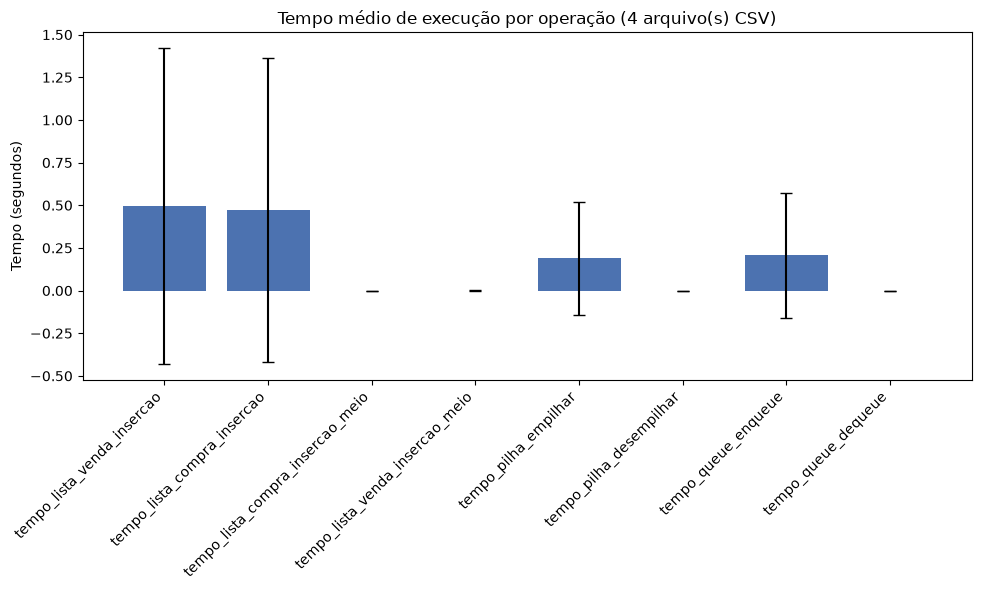

In [25]:
medias = df_resultados[colunas_tempo].mean()
desvios = df_resultados[colunas_tempo].std()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(medias.index, medias.values, yerr=desvios.values, capsize=4, color='#4C72B0')
ax.set_ylabel('Tempo (segundos)')
ax.set_title(f'Tempo médio de execução por operação ({len(arquivos_csv)} arquivo(s) CSV)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

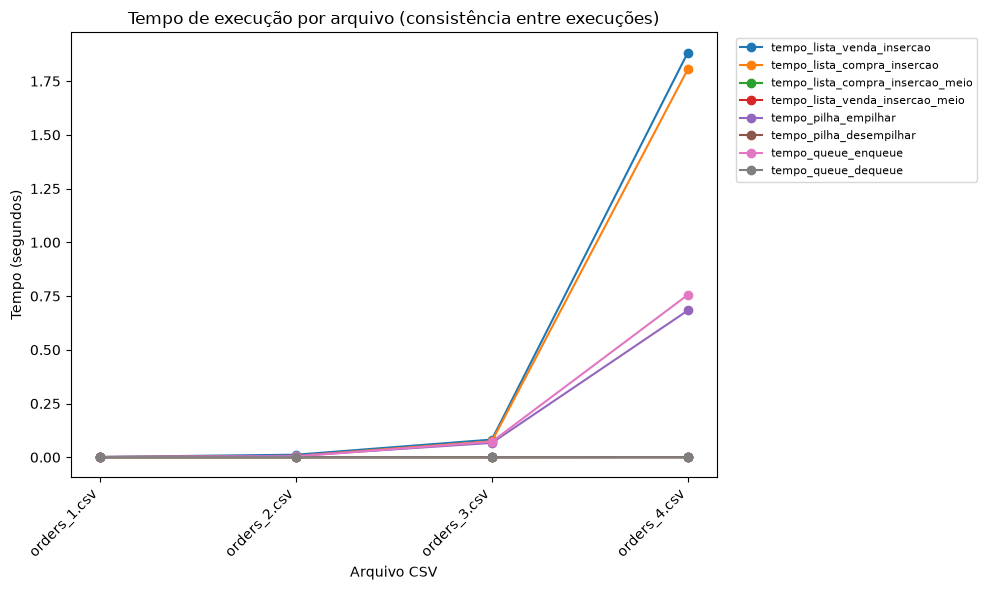

In [26]:
nomes_arquivos = [Path(a).name for a in df_resultados['arquivo']]

fig, ax = plt.subplots(figsize=(10, 6))
for coluna in colunas_tempo:
    ax.plot(nomes_arquivos, df_resultados[coluna], marker='o', label=coluna)

ax.set_ylabel('Tempo (segundos)')
ax.set_xlabel('Arquivo CSV')
ax.set_title('Tempo de execução por arquivo (consistência entre execuções)')
plt.xticks(rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
#df_resultados.to_csv('resultados_benchmark.csv', index=False)
#print("Resultados salvos em 'resultados_benchmark.csv'")

Resultados salvos em 'resultados_benchmark.csv'
